# Concours MTH3302

## Calepin de base (succinct)

In [34]:
using CSV, DataFrames
using Distributions, Gadfly, MLBase, Random, Statistics

In [35]:
train_data = CSV.read("train.csv", DataFrame, decimal=',')
test = CSV.read("test.csv", DataFrame, decimal=',');

Random.seed!(3302)
# Partager les données en données d'entraînement (80%) et de validation (20%)
train_id = sample(1:nrow(train_data), round(Int, .8*nrow(train_data)), ordered=true, replace=false)
valid_id = setdiff(1:nrow(train_data), train_id)

train = train_data[train_id,:]
valid = train_data[valid_id,:];
first(train, 5)

Row,annee,type,nombre_cylindres,cylindree,transmission,boite,consommation
,Int64,String31,Int64,Float64,String15,String15,Float64
1,2020,VUS_petit,4,2.0,integrale,automatique,9.80042
2,2021,voiture_compacte,6,3.3,propulsion,automatique,11.7605
3,2023,voiture_deux_places,8,5.0,integrale,automatique,13.0672
4,2022,voiture_moyenne,8,4.4,integrale,automatique,13.8359
5,2022,voiture_minicompacte,3,1.5,traction,automatique,7.35031


Data Exploration

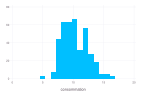

In [36]:
plot(train_data, x=:consommation, Geom.histogram(bincount=15))

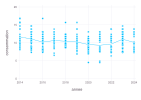

In [37]:
# Calculer la moyenne de la consommation
average_per_year = combine(groupby(train_data, :annee), :consommation => mean)

plot(
    layer(train_data, x=:annee, y=:consommation, Geom.point),
    layer(average_per_year, x=:annee, y=:consommation_mean, Geom.line),
    Guide.xlabel("annee"), Guide.ylabel("consommation")
)


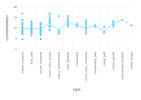

In [38]:
# analyser la consommation par type
average_per_type = combine(groupby(train_data, :type), :consommation => mean)
plot(
    layer(train_data, x=:type, y=:consommation, Geom.point),
    layer(average_per_type, x=:type, y=:consommation_mean, Geom.line),
    Guide.xlabel("type"), Guide.ylabel("consommation")
)

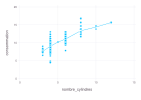

In [39]:
# analyser la consommation par nombre_cylindres
average_per_cylindres = combine(groupby(train_data, :nombre_cylindres), :consommation => mean)
plot(
    layer(train_data, x=:nombre_cylindres, y=:consommation, Geom.point),
    layer(average_per_cylindres, x=:nombre_cylindres, y=:consommation_mean, Geom.line),
    Guide.xlabel("nombre_cylindres"), Guide.ylabel("consommation")
)

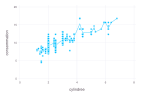

In [40]:
# analyser la consommation par cylindree
average_per_cylindree = combine(groupby(train, :cylindree), :consommation => mean)
plot(
    layer(train, x=:cylindree, y=:consommation, Geom.point),
    layer(average_per_cylindree, x=:cylindree, y=:consommation_mean, Geom.line),
    Guide.xlabel("cylindree"), Guide.ylabel("consommation")
)

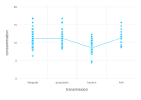

In [41]:
# Analyser la consommation par transmission
average_per_transmission = combine(groupby(train, :transmission), :consommation => mean)
plot(
    layer(train, x=:transmission, y=:consommation, Geom.point),
    layer(average_per_transmission, x=:transmission, y=:consommation_mean, Geom.line),
    Guide.xlabel("transmission"), Guide.ylabel("consommation")
)

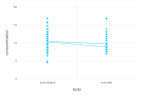

In [42]:
# Analyser la consommation par boite
average_per_boite = combine(groupby(train, :boite), :consommation => mean, :consommation => median)
plot(
    layer(train, x=:boite, y=:consommation, Geom.point),
    layer(average_per_boite, x=:boite, y=:consommation_median, Geom.line),
    layer(average_per_boite, x=:boite, y=:consommation_mean, Geom.line),
    Guide.xlabel("boite"), Guide.ylabel("consommation")
)

# Régression linéaire avec une seule variable explicative : nombre de cylindres

In [43]:
x = train.nombre_cylindres
y = train.consommation

n = length(y)

317

## Ajustement sur l'ensemble d'entraînement

In [44]:
using Statistics

ȳ = mean(y)
X = hcat(ones(n), x)

β̂ = X\y;

## Prédiction sur l'ensemble de test

In [45]:
x = test.nombre_cylindres
n = length(x)

X = hcat(ones(n), x)
ŷ = X*β̂

150-element Vector{Float64}:
  9.04089275213257
  9.04089275213257
  9.04089275213257
  9.04089275213257
 13.139738103477603
 13.139738103477603
 13.139738103477603
  9.04089275213257
 11.090315427805088
 15.189160779150118
  ⋮
  9.04089275213257
  9.04089275213257
  9.04089275213257
  9.04089275213257
  9.04089275213257
 11.090315427805088
 11.090315427805088
  8.016181414296314
  9.04089275213257

# Création du fichier de prédictions

In [46]:
id = 1:n

df_pred = DataFrame(id=id, consommation=ŷ)

CSV.write("benchmark.csv", df_pred)

"benchmark.csv"